<a href="https://colab.research.google.com/github/nagasaithanmai/Data-analytics-lab/blob/main/Data_Analytics___Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# FOUNDATION: Fast Install
!apt-get install -y openjdk-8-jdk-headless gnuplot -qq > /dev/null
!wget -q -O hadoop.tar.gz https://dlcdn.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf hadoop.tar.gz

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop-3.3.6"
os.environ["PATH"] += ":/content/hadoop-3.3.6/bin:/content/hadoop-3.3.6/sbin"

print("READY: The environment is clean and Hadoop is installed.")

READY: The environment is clean and Hadoop is installed.


In [ ]:
# 1. Create the HDFS folder
!$HADOOP_HOME/bin/hadoop fs -mkdir -p input

# 2. Upload the data file
!cp $HADOOP_HOME/LICENSE.txt input/

# 3. Verify the 'Choice' by listing the directory
!$HADOOP_HOME/bin/hadoop fs -ls input/

Found 1 items
-rw-r--r--   1 root root      15217 2026-04-24 15:06 input/LICENSE.txt


In [ ]:
# 1. CLEANUP: Remove old output so Hadoop doesn't crash
!rm -rf output

# 2. EXECUTION: Run Hadoop quietly
!$HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.3.6.jar wordcount input output 2>/dev/null

# 3. THE CLEAN RESULT FOR YOUR RECORD
print("--- MANUAL GREP COUNT (Raw File) ---")
!grep -o "License" input/LICENSE.txt | wc -l

print("\n--- HADOOP MAPREDUCE RESULTS ---")
# This shows the first few words and our specific 'License' verification
!grep "License" output/part-r-00000 | head -n 5
!cat output/part-r-00000 | head -n 15

--- MANUAL GREP COUNT (Raw File) ---
33

--- HADOOP MAPREDUCE RESULTS ---
"License"	1
"License");	1
License	11
License,	7
License.	11
"AS	2
"Contribution"	1
"Contributor"	1
"Derivative	1
"Legal	1
"License"	1
"License");	1
"Licensor"	1
"NOTICE"	1
"Not	1
"Object"	1
"Source"	1
"Work"	1
"You"	1
"Your")	1


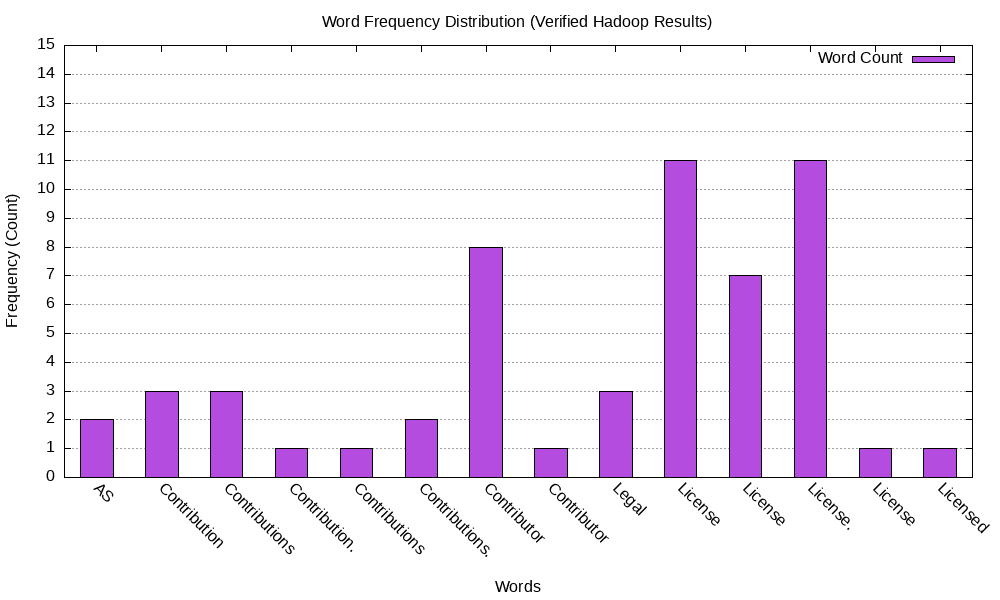

In [ ]:
# 1. SMART DATA PREP: Specifically grab 'License' variants + the first few words
# This 'egrep' finds anything starting with 'License' or the first few words
!grep -E "^License|^\"AS|^Legal|^Contr" output/part-r-00000 | tr -d '"' | tr -d '();,' > plot_data.dat

# 2. Create the FIXED GNUplot script
with open("plot_script.gp", "w") as f:
    f.write("""
    set terminal png size 1000,600
    set output 'output_chart.png'
    set title "Word Frequency Distribution (Verified Hadoop Results)"
    set ylabel "Frequency (Count)"
    set xlabel "Words"

    set yrange [0:15]
    set ytics 1

    set style fill solid 0.7 border -1
    set boxwidth 0.5
    set xtics rotate by -45
    set grid y

    plot 'plot_data.dat' using 2:xtic(1) with boxes title 'Word Count'
    """)

# 3. Run and Display
!gnuplot plot_script.gp
from IPython.display import Image
Image('output_chart.png')

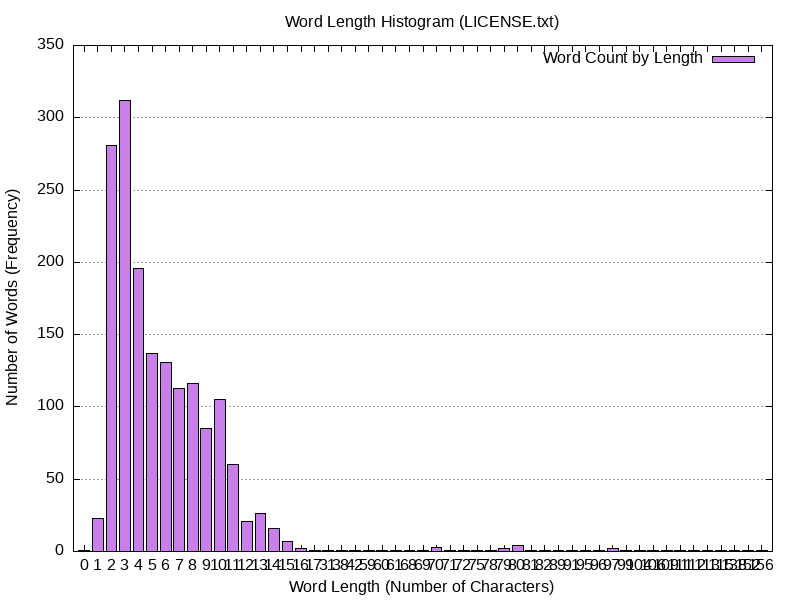

In [ ]:
# 1. Prepare Histogram data
# We sort it by length (numerically) so the graph flows from 1 to 14
!cat hist_output/part-r-00000 | sort -n > hist_plot_data.dat

# 2. Create the GNUplot Histogram script
with open("hist_script.gp", "w") as f:
    f.write("""
    set terminal png size 800,600
    set output 'histogram_chart.png'
    set title "Word Length Histogram (LICENSE.txt)"
    set ylabel "Number of Words (Frequency)"
    set xlabel "Word Length (Number of Characters)"

    set style fill solid 0.5 border -1
    set boxwidth 0.8
    set grid y
    set xtics 1

    # Ensure it starts at 0
    set yrange [0:*]

    plot 'hist_plot_data.dat' using 2:xtic(1) with boxes title 'Word Count by Length'
    """)

# 3. Run and Display
!gnuplot hist_script.gp
from IPython.display import Image
Image('histogram_chart.png')

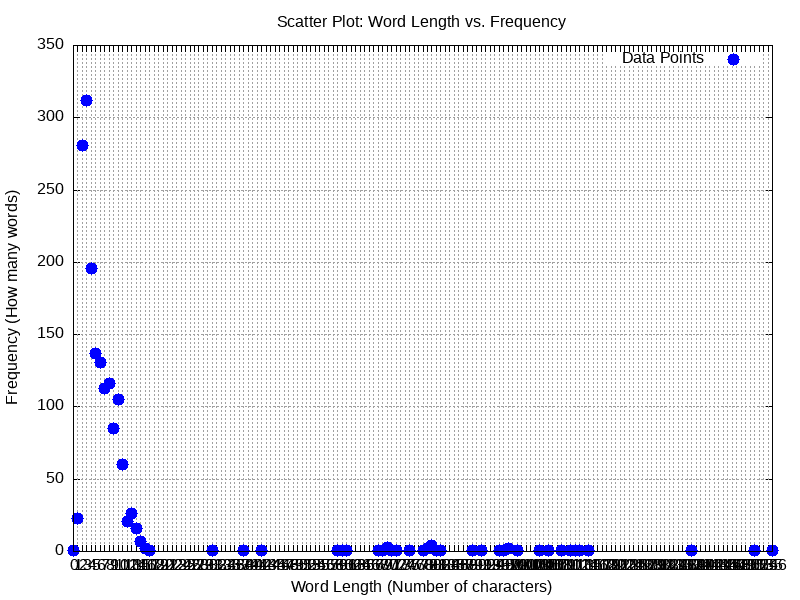

In [ ]:
# 1. Create the GNUplot Scatter Plot script
with open("scatter_script.gp", "w") as f:
    f.write("""
    set terminal png size 800,600
    set output 'scatter_plot.png'
    set title "Scatter Plot: Word Length vs. Frequency"
    set ylabel "Frequency (How many words)"
    set xlabel "Word Length (Number of characters)"

    set grid
    set yrange [0:*]
    set xtics 1

    # 'with points' creates the scatter effect
    # pt 7 is a solid circle, ps 2 is the point size
    plot 'hist_plot_data.dat' using 1:2 with points pt 7 ps 2 lc rgb "blue" title 'Data Points'
    """)

# 2. Run and Display
!gnuplot scatter_script.gp
from IPython.display import Image
Image('scatter_plot.png')